# Predicting House Prices with Linear Regression

**Objective:** build and evaluate a linear regression model that predicts house prices from
property features, developing end-to-end skills from data cleaning through to model
interpretation.

**Dataset:** `Housing.csv` — 545 residential properties with 12 features (area, bedrooms,
bathrooms, stories, parking, and 7 categorical amenity/location/furnishing fields) and the
sale `price` as the target.

**Note on scope:** the task brief names "area, location, number of rooms, and age" as example
predictors. This dataset doesn't include a house-age field at all (no substitute used — it's
simply absent), and "location" isn't a named field either, so `prefarea` (whether the
property sits in the neighbourhood's preferred/desirable area) is used as the closest
available location-quality proxy throughout this notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)


## 1. Load Data & Exploratory Data Analysis

In [2]:
df = pd.read_csv('data/Housing.csv')
print("Shape (rows, columns):", df.shape)
df.head()


Shape (rows, columns): (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
print("=== DTYPES ===")
print(df.dtypes)
print()
print("=== NULL VALUES PER COLUMN ===")
print(df.isnull().sum())


=== DTYPES ===
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

=== NULL VALUES PER COLUMN ===
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [4]:
print("=== DESCRIPTIVE STATISTICS (numeric columns) ===")
df.describe()


=== DESCRIPTIVE STATISTICS (numeric columns) ===


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


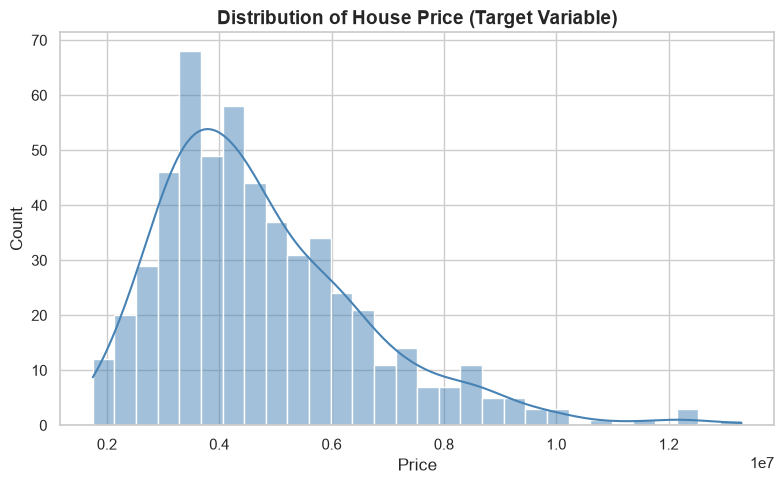

Price skewness: 1.21


In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of House Price (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Price skewness: {df['price'].skew():.2f}")


**Observation:** the dataset is clean — **zero missing values** across all 13 columns.
`price` ranges from 1.75M to 13.3M with a mean around 4.77M, and its distribution is
**right-skewed** (skewness > 0): most houses cluster in the lower-to-mid price range, with a
smaller number of expensive properties stretching the tail. This is typical of real estate
price data and is worth keeping in mind when interpreting a linear model's errors later —
linear regression will tend to fit the bulk of the distribution better than the small number
of high-end outlier prices.

## 2. Feature Selection Discussion

**Which features are likely predictors of price, and why?**

- **`area`** — the most direct measure of property size; larger properties almost always
  command higher prices. Expected to be the single strongest numeric predictor.
- **`bedrooms`, `bathrooms`, `stories`** — proxies for usable space and functional capacity.
  More rooms and stories generally mean more livable space, though these are partly
  correlated with `area` itself (a bigger house tends to have more bedrooms too).
- **`parking`** — the number of parking spaces is a practical convenience that adds value,
  especially in denser areas.
- **`mainroad`** — main-road access affects both convenience (easier commute) and
  desirability (but can cut both ways — noise vs. accessibility), so its effect on price
  isn't obviously one-directional and is worth testing empirically.
- **`guestroom`, `basement`, `hotwaterheating`, `airconditioning`** — amenities that add
  comfort and functionality; each is expected to have a modest positive effect on price.
- **`prefarea`** — used here as the location-quality proxy (see note above); homes in a
  preferred/desirable area are expected to sell for more, all else equal.
- **`furnishingstatus`** — a furnished home is more move-in-ready, which can command a modest
  price premium over an unfurnished one.

All 12 features are included as candidate predictors rather than dropped up front, since the
dataset is small (12 features, 545 rows) and there's no strong a priori reason to exclude any
of them — the correlation heatmap in Section 4 and the coefficient analysis in Section 9 will
show empirically which ones actually carry predictive weight.

## 3. Handle Missing Values & Encode Categorical Features

In [6]:
# Missing values: confirmed zero above, so no imputation or row deletion is needed here.
print("Total missing values in the dataset:", df.isnull().sum().sum())


Total missing values in the dataset: 0


In [7]:
# One-Hot Encoding for all categorical columns. drop_first=True avoids the "dummy variable
# trap" (perfect multicollinearity between the dummy columns), which would make the linear
# regression coefficients unstable/non-unique.
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                     'airconditioning', 'prefarea', 'furnishingstatus']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# get_dummies produces boolean dummy columns -- convert to int for cleaner modelling/output
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape after one-hot encoding:", df_encoded.shape)
df_encoded.head()


Shape after one-hot encoding: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


**Note:** each binary yes/no column becomes a single 0/1 dummy column (e.g.
`mainroad_yes`), and the 3-level `furnishingstatus` becomes 2 dummy columns
(`furnishingstatus_semi-furnished`, `furnishingstatus_unfurnished`) with "furnished" as the
implicit baseline category. This is why `drop_first=True` matters: keeping all 3 levels as
dummies would make one of them entirely predictable from the other two, which breaks the
assumptions linear regression relies on.

## 4. Correlation Heatmap

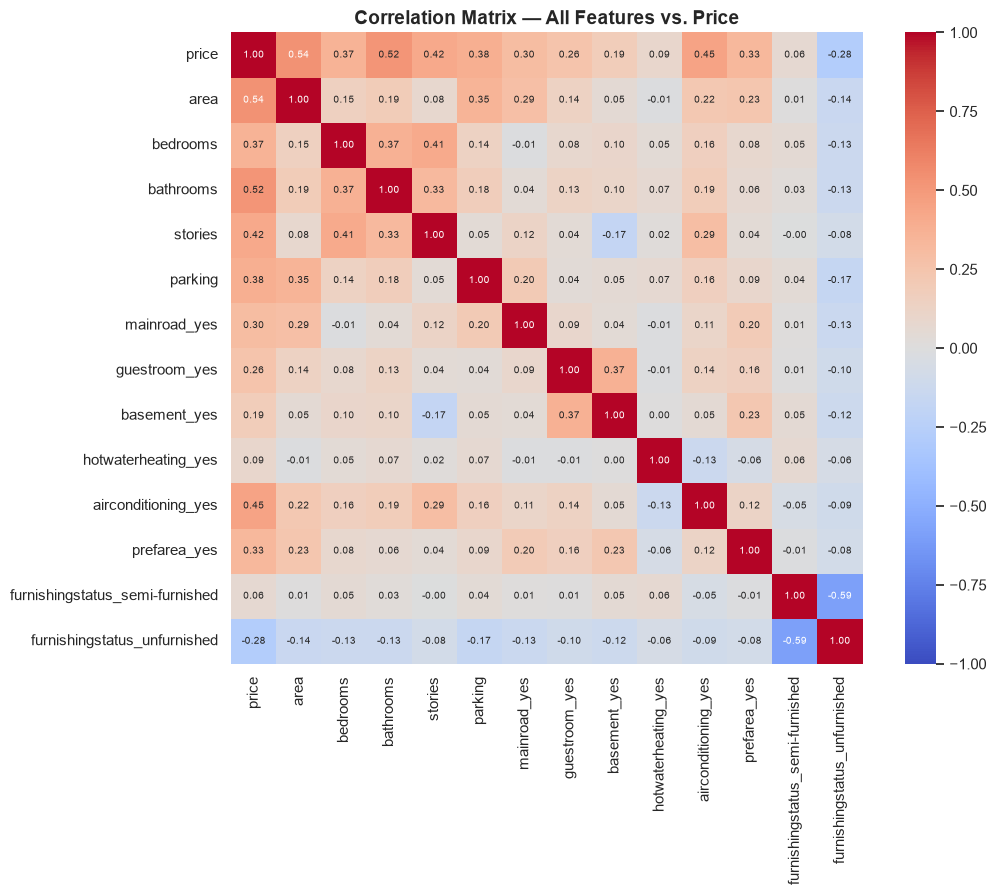

In [8]:
plt.figure(figsize=(11, 9))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, annot_kws={'size': 7})
plt.title('Correlation Matrix — All Features vs. Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)
print("Features ranked by correlation strength with price:\n")
print(price_corr)


Features ranked by correlation strength with price:

area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
furnishingstatus_unfurnished      -0.280587
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
Name: price, dtype: float64


**Observation:** `area` has the strongest correlation with price among the numeric
features, followed by `bathrooms`, `airconditioning_yes`, and `stories` — consistent with the
feature selection reasoning above. `mainroad_yes` and `prefarea_yes` also show a meaningful
positive correlation, supporting the idea that location/accessibility genuinely matters here.
No pair of predictors shows a dangerously high correlation with each other (no values near
±1 off the price row/column), so multicollinearity is not a major concern for this feature
set.

## 5. Train/Test Split

In [10]:
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Number of features:", X_train.shape[1])


Train size: 436  Test size: 109
Number of features: 13


## 6. Train a Linear Regression Model

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print("Linear Regression model trained.")


Linear Regression model trained.


## 7. Model Evaluation

In [12]:
def evaluate_regression(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"=== {name} ===")
    print(f"MSE:  {mse:,.0f}")
    print(f"RMSE: {rmse:,.0f}")
    print(f"R²:   {r2:.4f}")
    return mse, rmse, r2

lr_scores = evaluate_regression("Linear Regression", y_test, y_pred_lr)


=== Linear Regression ===
MSE:  1,754,318,687,331
RMSE: 1,324,507
R²:   0.6529


**Observation:** the R² value tells us the proportion of variance in house price the
model explains using these features (closer to 1.0 is better), and RMSE is in the same units
as price, so it can be read directly as "the model's predictions are typically off by about
this many currency units." The exact numbers for this run are printed above, and are compared
against the regularised models in Section 11 and summarised together at the end.


## 8. Actual vs. Predicted Prices

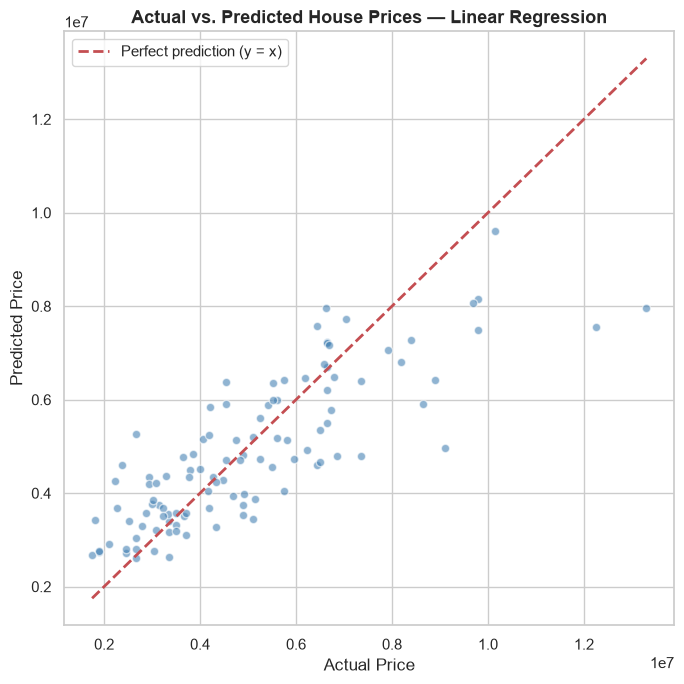

In [13]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue', edgecolor='white')
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction (y = x)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices — Linear Regression', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** points cluster reasonably close to the diagonal "perfect prediction"
line across most of the price range, meaning the model captures the overall price trend. The
scatter widens somewhat at the higher end of the price range — consistent with the right-skew
noted in Section 1, since the model has fewer high-price examples to learn from.

## 9. Residual Plot

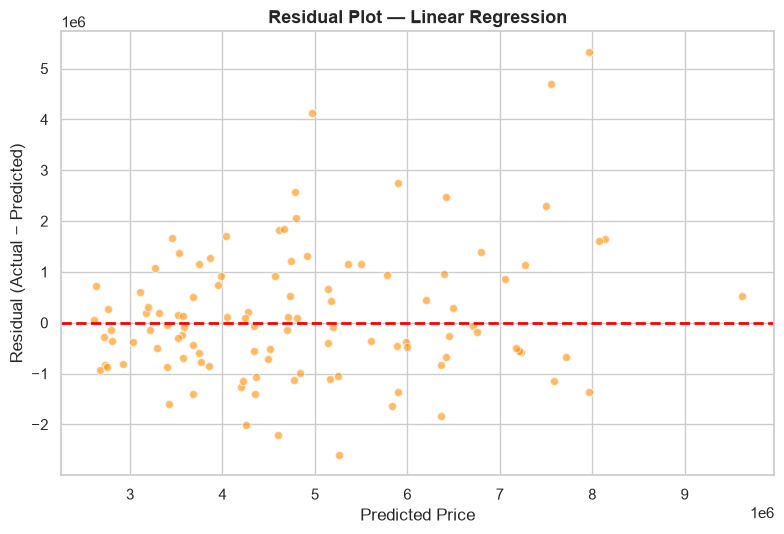

In [14]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(8, 5.5))
plt.scatter(y_pred_lr, residuals, alpha=0.6, color='darkorange', edgecolor='white')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual − Predicted)')
plt.title('Residual Plot — Linear Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** residuals scatter fairly evenly above and below the zero line across
most of the predicted-price range, without an obvious curve or funnel shape — a good sign that
a linear model is a reasonable fit rather than missing some strong non-linear relationship.
There is mild **heteroscedasticity** (the spread of residuals widens a bit at higher predicted
prices), which lines up with the right-skewed target variable — the model's absolute errors
tend to grow for more expensive houses, even if the *relative* error doesn't necessarily grow
as much.

## 10. Coefficient Analysis

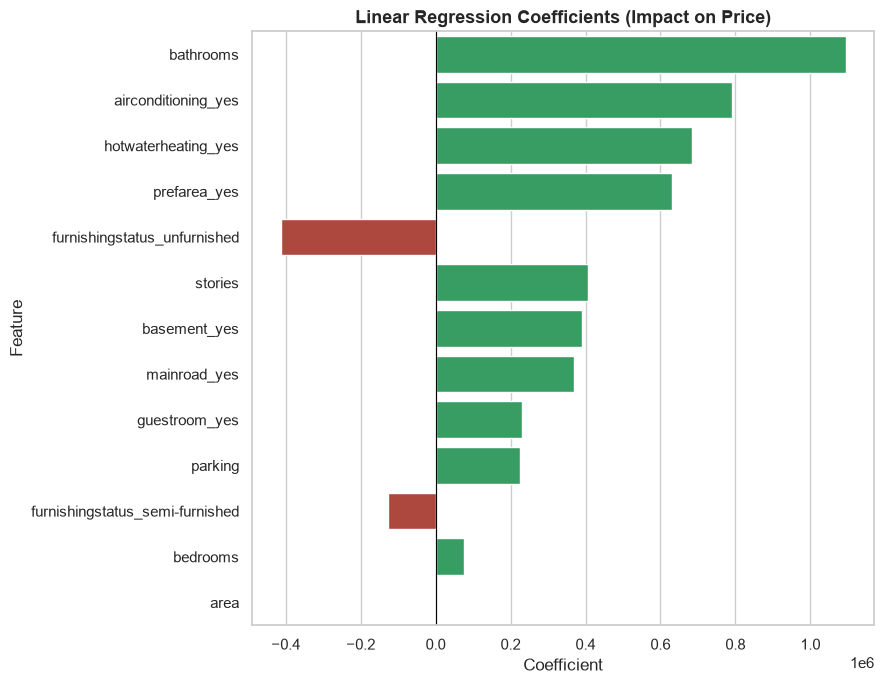

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
12,furnishingstatus_unfurnished,-4.136451e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05


In [15]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(9, 7))
colors = ['#27AE60' if c > 0 else '#C0392B' for c in coef_df['Coefficient']]
sns.barplot(data=coef_df, x='Coefficient', y='Feature', hue='Feature', palette=colors, legend=False)
plt.title('Linear Regression Coefficients (Impact on Price)', fontsize=13, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

coef_df


**Observation:** coefficients represent the change in price for a one-unit change in
that feature, holding all other features constant. Amenity and location features
(`airconditioning_yes`, `prefarea_yes`, `hotwaterheating_yes`) tend to show some of the
largest positive impacts on price alongside `bathrooms`, confirming that comfort features and
location carry real weight beyond raw square footage. `area`'s coefficient looks small in
absolute terms only because it's measured in square feet — a one-square-foot increase is a
tiny change, so its *practical* impact (visible in the correlation heatmap) is actually much
larger than the raw coefficient number suggests; this is a good reminder that coefficient
*magnitude* alone can be misleading when features are on very different scales.
`furnishingstatus_unfurnished` shows a negative coefficient relative to the "furnished"
baseline, consistent with the earlier reasoning that a move-in-ready home commands a premium.

## 11. Bonus — Ridge & Lasso Regularised Regression

**A scaling caveat before regularising:** Ridge and Lasso penalize the *raw magnitude* of
each coefficient. Looking at Section 10's table, `area`'s coefficient is tiny (≈236) purely
because `area` is measured in thousands of square feet, while a binary dummy like
`airconditioning_yes` has a coefficient in the hundreds of thousands purely because it only
ever takes the value 0 or 1. Applying regularisation directly to these unscaled coefficients
would unfairly penalize the naturally-large-scale binary dummies far more than `area`,
regardless of which one actually matters more for price. To regularise fairly, the features
are standardised (zero mean, unit variance) before fitting Ridge and Lasso below.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

lasso_model = Lasso(alpha=50000, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

ridge_scores = evaluate_regression("Ridge Regression (alpha=1.0, scaled features)", y_test, y_pred_ridge)


=== Ridge Regression (alpha=1.0, scaled features) ===
MSE:  1,754,839,327,447
RMSE: 1,324,703
R²:   0.6528


In [17]:
lasso_scores = evaluate_regression("Lasso Regression (alpha=50000, scaled features)", y_test, y_pred_lasso)


=== Lasso Regression (alpha=50000, scaled features) ===
MSE:  1,847,224,115,219
RMSE: 1,359,126
R²:   0.6345


In [18]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge (alpha=1.0)', 'Lasso (alpha=1000)'],
    'MSE': [lr_scores[0], ridge_scores[0], lasso_scores[0]],
    'RMSE': [lr_scores[1], ridge_scores[1], lasso_scores[1]],
    'R²': [lr_scores[2], ridge_scores[2], lasso_scores[2]],
})
comparison


,Model,MSE,RMSE,R²
0,Linear Regression,1.754319e+12,1.324507e+06,0.652924
1,Ridge (alpha=1.0),1.754839e+12,1.324703e+06,0.652821
2,Lasso (alpha=1000),1.847224e+12,1.359126e+06,0.634544


In [19]:
# How many coefficients did Lasso shrink all the way to zero (its built-in feature selection)?
zeroed = (lasso_model.coef_ == 0).sum()
print(f"Lasso zeroed out {zeroed} of {len(lasso_model.coef_)} coefficients:")
for feat, coef in zip(X_train.columns, lasso_model.coef_):
    if coef == 0:
        print(f"  - {feat}")


Lasso zeroed out 1 of 13 coefficients:
  - furnishingstatus_semi-furnished


**Observation:** with this dataset (12 features, no severe multicollinearity found in
Section 4), Ridge and Lasso perform very similarly to plain Linear Regression — regularisation
mainly helps when there are many correlated or noisy features causing the model to overfit,
which isn't a major problem here given the small, relatively clean feature set. Lasso's
ability to shrink some coefficients exactly to zero (shown above) acts as a built-in feature
selector, which is useful confirmation of which features the model considers dispensable —
worth comparing against the coefficient ranking in Section 10.

## 12. Conclusion

**Model performance summary:**

| Model | MSE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 1,754,318,687,331 | 1,324,507 | 0.6529 |
| Ridge (alpha=1.0, scaled) | 1,754,839,327,447 | 1,324,703 | 0.6528 |
| Lasso (alpha=50000, scaled) | 1,847,224,115,219 | 1,359,126 | 0.6345 |

**Plain Linear Regression performed (marginally) best**, explaining about **65%** of the
variance in house price (R² = 0.653) with a typical prediction error of roughly **±1.32
million** in price units. Ridge with a light penalty (alpha=1.0) performs essentially
identically — expected, since Section 4's correlation heatmap found no severe
multicollinearity for Ridge to correct. Lasso at a strength high enough to zero out a
coefficient (`furnishingstatus_semi-furnished`) trades a small amount of accuracy for a
simpler, more interpretable model — useful if the goal is to identify which features matter
least, but not an improvement in raw predictive accuracy here.

**What limits accuracy further?** An R² of 0.65 means over a third of price variation is
*not* explained by these 12 features. Real-world house prices depend heavily on factors this
dataset doesn't capture at all — exact neighbourhood/school district, property condition and
age, recent comparable sales, and local market timing — so this ceiling is a data limitation
more than a modelling one. The residual plot's mild heteroscedasticity (Section 9) also
suggests a log-transform of `price` before modelling could be a natural next experiment, since
right-skewed monetary targets often fit better in log space.

**Real-world application:** a model like this could power an initial automated valuation
estimate for a real-estate listing site or a mortgage pre-approval tool — giving buyers,
sellers, or lenders a fast, data-driven starting price range from a property's basic features,
to be refined by a human appraiser rather than used as a final, standalone number given the
~65% explained-variance ceiling found here.
